# 🚗 Advanced Behavior Planning with Finite State Machines
### Cost-Based Transitions, Highway Scenario, and Graph Visualization

In this notebook, we extend the earlier behavior-planning notebook by:
- Defining a richer **Finite State Machine (FSM)** with states:
  - `CRUISE`, `FOLLOW`, `STOP`, `LANE_CHANGE_LEFT`, `LANE_CHANGE_RIGHT`, `ACCELERATE`
- Building a **state transition graph with costs** and visualizing it
- Creating a simple **highway scenario** with randomly placed vehicles on three lanes
- Implementing a **cost-based FSM** that chooses the next behavior based on distances to nearby cars
- Reusing the **SM pattern** similar to the robot-control state machine (start, step, transduce)

This is designed as a teaching notebook for behavior planning in autonomous driving.

## 1. Define States and a Transition Graph with Base Costs
We first define all behavior states and a nominal transition-cost graph.
These costs can be interpreted as "how expensive" it is to switch from one behavior to another.
Later, we will *augment* these costs with traffic-dependent penalties.

In [ ]:
states = [
    'CRUISE',
    'FOLLOW',
    'STOP',
    'LANE_CHANGE_LEFT',
    'LANE_CHANGE_RIGHT',
    'ACCELERATE'
]

# Base (nominal) transition cost table: lower = more preferred
# This is a simple, hand-crafted example.
base_transition_cost = {s: {} for s in states}

def set_cost(s_from, s_to, cost):
    base_transition_cost[s_from][s_to] = cost

for s in states:
    set_cost(s, s, 1.0)  # staying in same state is usually cheap

# Some reasonable preferences
set_cost('CRUISE', 'FOLLOW', 2.0)
set_cost('CRUISE', 'ACCELERATE', 2.0)
set_cost('CRUISE', 'LANE_CHANGE_LEFT', 3.0)
set_cost('CRUISE', 'LANE_CHANGE_RIGHT', 3.0)
set_cost('CRUISE', 'STOP', 5.0)

set_cost('FOLLOW', 'CRUISE', 2.0)
set_cost('FOLLOW', 'LANE_CHANGE_LEFT', 2.5)
set_cost('FOLLOW', 'LANE_CHANGE_RIGHT', 2.5)
set_cost('FOLLOW', 'STOP', 4.0)

set_cost('STOP', 'CRUISE', 2.0)
set_cost('STOP', 'ACCELERATE', 1.5)

set_cost('LANE_CHANGE_LEFT', 'CRUISE', 2.0)
set_cost('LANE_CHANGE_RIGHT', 'CRUISE', 2.0)

set_cost('ACCELERATE', 'CRUISE', 1.5)
set_cost('ACCELERATE', 'FOLLOW', 3.0)

base_transition_cost

{'CRUISE': {'CRUISE': 1.0,
  'FOLLOW': 2.0,
  'ACCELERATE': 2.0,
  'LANE_CHANGE_LEFT': 3.0,
  'LANE_CHANGE_RIGHT': 3.0,
  'STOP': 5.0},
 'FOLLOW': {'FOLLOW': 1.0,
  'CRUISE': 2.0,
  'LANE_CHANGE_LEFT': 2.5,
  'LANE_CHANGE_RIGHT': 2.5,
  'STOP': 4.0},
 'STOP': {'STOP': 1.0, 'CRUISE': 2.0, 'ACCELERATE': 1.5},
 'LANE_CHANGE_LEFT': {'LANE_CHANGE_LEFT': 1.0, 'CRUISE': 2.0},
 'LANE_CHANGE_RIGHT': {'LANE_CHANGE_RIGHT': 1.0, 'CRUISE': 2.0},
 'ACCELERATE': {'ACCELERATE': 1.0, 'CRUISE': 1.5, 'FOLLOW': 3.0}}

### Visualize the State Transition Graph
We visualize the FSM as a directed graph with edges labeled by base costs.
We use `networkx` for the graph structure and `matplotlib` for drawing.

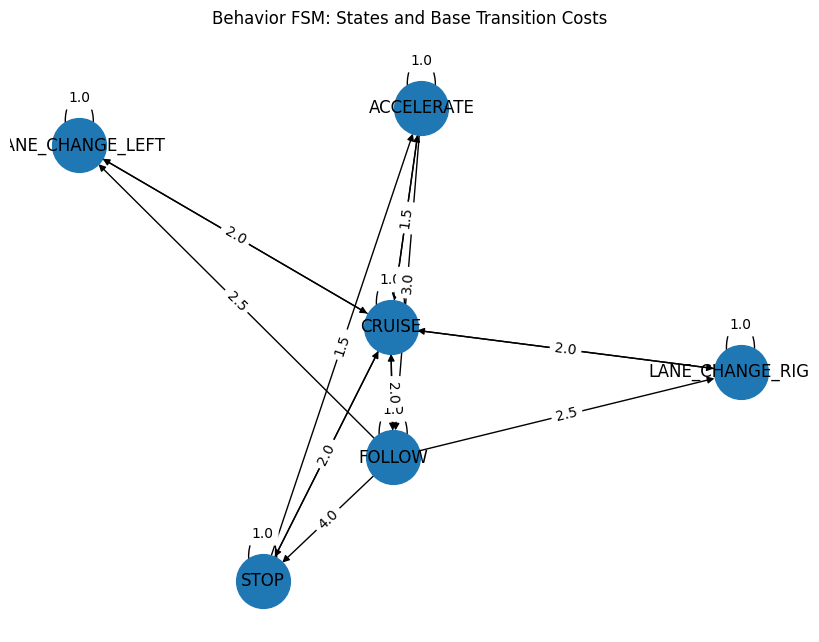

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
for s in states:
    G.add_node(s)

for s_from, targets in base_transition_cost.items():
    for s_to, cost in targets.items():
        G.add_edge(s_from, s_to, weight=cost, label=str(cost))

pos = nx.spring_layout(G, seed=0)  # layout for visualization

plt.figure(figsize=(8,6))
nx.draw(G, pos, with_labels=True, node_size=1500, arrows=True)
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title("Behavior FSM: States and Base Transition Costs")
plt.axis('off')
plt.show()

## 2. Highway Scenario: Three-Lane One-Way Road with Random Cars
We now create a very simple 1D highway world:
- 3 lanes: `lane = 0, 1, 2`
- A single **ego vehicle** we control
- Multiple other vehicles placed randomly along the lanes

We track positions along the road with `s` (longitudinal distance).

In [ ]:
import numpy as np
import random

class Vehicle:
    def __init__(self, lane, s, speed, is_ego=False):
        self.lane = lane        # 0,1,2
        self.s = s              # longitudinal position
        self.speed = speed      # m/s (simplified)
        self.is_ego = is_ego

def create_highway(num_vehicles=15, length=300.0, lanes=3):
    vehicles = []
    # ego in middle lane near the start
    ego = Vehicle(lane=1, s=10.0, speed=20.0, is_ego=True)
    vehicles.append(ego)

    for _ in range(num_vehicles):
        lane = random.randint(0, lanes-1)
        s = random.uniform(20.0, length)  # ahead of ego
        speed = random.uniform(10.0, 30.0)
        vehicles.append(Vehicle(lane, s, speed))
    return vehicles, ego

vehicles, ego = create_highway()
len(vehicles)

16

### Visualize the Highway Snapshot
We draw lanes as horizontal lines and vehicles as points.
- x-axis: `s` (along the road)
- y-axis: lane index

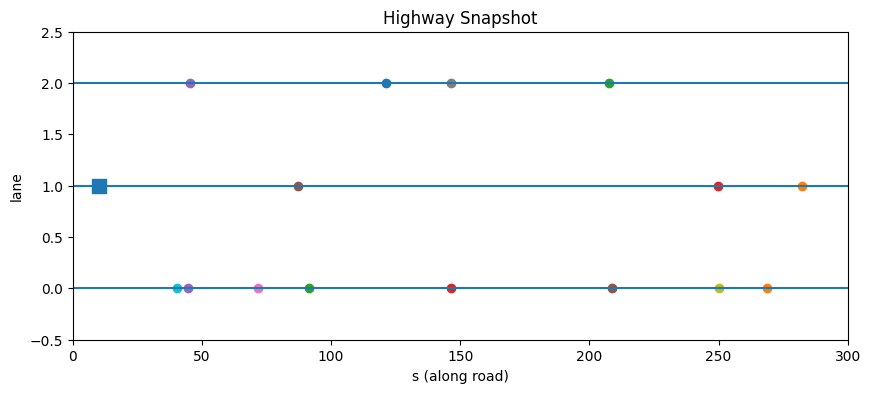

In [ ]:
def plot_highway(vehicles, ego, length=300.0, lanes=3):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10,4))
    for lane in range(lanes):
        plt.hlines(lane, 0, length)
    for v in vehicles:
        if v.is_ego:
            plt.scatter(v.s, v.lane, marker='s', s=100, label='ego')
        else:
            plt.scatter(v.s, v.lane)
    plt.xlim(0, length)
    plt.ylim(-0.5, lanes-0.5)
    plt.xlabel('s (along road)')
    plt.ylabel('lane')
    plt.title('Highway Snapshot')
    plt.show()

plot_highway(vehicles, ego)

## 3. Perception: Distances to Vehicles in Same and Adjacent Lanes
Our FSM uses **distances** to vehicles ahead in the same lane and adjacent lanes:
- `d_same`: distance to nearest car ahead in current lane
- `d_left`: distance to nearest car ahead in left lane (if exists)
- `d_right`: distance to nearest car ahead in right lane (if exists)

If no vehicle is found ahead in a lane, we treat the distance as a large number ("no constraint").

In [ ]:
def compute_distances(vehicles, ego, lanes=3, max_dist=1e6):
    d_same = max_dist
    d_left = max_dist
    d_right = max_dist

    for v in vehicles:
        if v.is_ego:
            continue
        if v.s > ego.s:
            gap = v.s - ego.s
            if v.lane == ego.lane and gap < d_same:
                d_same = gap
            if v.lane == ego.lane - 1 and gap < d_left:
                d_left = gap
            if v.lane == ego.lane + 1 and gap < d_right:
                d_right = gap
    return d_same, d_left, d_right

d_same, d_left, d_right = compute_distances(vehicles, ego)
d_same, d_left, d_right

(77.26321856594022, 30.1587831215235, 35.31551630760696)

## 4. Cost-Based State Machine Using SM Pattern
We now reuse the **`SM` pattern** (similar to the robot-control notebook):

```python
class SM():
  def start(self):
    self.state = self.startstate
  def step(self, input):
    (s, o) = self.getNextValue(self.state, input)
    self.state = s
    return o
  def transduce(self, inputs):
    self.start()
    return [self.step(i) for i in inputs]
```

Our **BehaviorSM** chooses the next state by evaluating a cost for each possible transition:

\( \text{TotalCost}(s_\text{current} \rightarrow s_\text{next}) = \text{baseCost} + \text{trafficPenalty}(s_\text{current}, s_\text{next}, \text{distances}) \)

and picking the `next_state` with the lowest cost.

In [ ]:
class SM:
    def start(self):
        self.state = self.startstate
    def step(self, inp):
        (new_state, output) = self.getNextValue(self.state, inp)
        self.state = new_state
        return output
    def transduce(self, inputs):
        self.start()
        outputs = []
        for i in inputs:
            outputs.append(self.step(i))
        return outputs

In [ ]:
SAFE_FOLLOW_DIST = 25.0
SAFE_LANECHANGE_DIST = 30.0

def traffic_penalty(current, nxt, d_same, d_left, d_right):
    penalty = 0.0

    # Encourage STOP if extremely close
    if d_same < 5.0 and nxt != 'STOP':
        penalty += 50.0

    # FOLLOW is good if there is a car within safe distance ahead
    if nxt == 'FOLLOW':
        if d_same < SAFE_FOLLOW_DIST:
            penalty += 0.0
        else:
            penalty += 5.0  # no need to follow if no car ahead

    # CRUISE prefers clear road ahead
    if nxt == 'CRUISE':
        if d_same < SAFE_FOLLOW_DIST:
            penalty += 10.0  # cruising too close is bad

    # ACCELERATE requires lots of space ahead
    if nxt == 'ACCELERATE':
        if d_same < SAFE_FOLLOW_DIST:
            penalty += 20.0

    # Lane change left
    if nxt == 'LANE_CHANGE_LEFT':
        # cannot change left from leftmost lane
        if lane_index is not None and lane_index == 0:
            penalty += 100.0
        # must have enough distance in left lane
        if d_left < SAFE_LANECHANGE_DIST:
            penalty += 30.0

    # Lane change right
    if nxt == 'LANE_CHANGE_RIGHT':
        # cannot change right from rightmost lane
        if lane_index is not None and lane_index == 2:
            penalty += 100.0
        if d_right < SAFE_LANECHANGE_DIST:
            penalty += 30.0

    # Slight inertia penalty for changing state too often
    if nxt != current:
        penalty += 0.5

    return penalty

> **Note:** In the function above, we referenced `lane_index` as a global. We'll set it from the ego vehicle before calling the FSM cost computation.

In [ ]:
class BehaviorSM(SM):
    def __init__(self):
        self.startstate = 'CRUISE'

    def getNextValue(self, state, inp):
        # inp is a dict with distances and lane index and speed
        d_same = inp['d_same']
        d_left = inp['d_left']
        d_right = inp['d_right']
        lane = inp['lane']
        speed = inp['speed']

        # set global lane_index for penalty function
        global lane_index
        lane_index = lane

        best_state = state
        best_cost = float('inf')

        for nxt in states:
            # skip obviously meaningless transitions (optional)
            base = base_transition_cost.get(state, {}).get(nxt, 10.0)
            pen = traffic_penalty(state, nxt, d_same, d_left, d_right)
            cost = base + pen
            if cost < best_cost:
                best_cost = cost
                best_state = nxt

        # output is chosen next_state
        return best_state, best_state

## 5. Simulating the Ego Vehicle on the Highway
We now simulate several steps:
- At each step, we recompute distances to nearby vehicles
- Provide this as input to the `BehaviorSM`
- The FSM chooses the next behavior state
- Based on the state, we update the ego speed and lane (very simplified)
- We record the ego state over time and visualize it


In [ ]:
def simulate(steps=30, length=300.0, lanes=3):
    vehicles, ego = create_highway(num_vehicles=20, length=length, lanes=lanes)
    sm = BehaviorSM()
    sm.start()

    history = {
        'time': [],
        's': [],
        'lane': [],
        'speed': [],
        'state': []
    }

    dt = 1.0  # 1 second time step

    for t in range(steps):
        d_same, d_left, d_right = compute_distances(vehicles, ego, lanes=lanes)
        inp = {
            'd_same': d_same,
            'd_left': d_left,
            'd_right': d_right,
            'lane': ego.lane,
            'speed': ego.speed
        }
        state = sm.step(inp)

        # Simple dynamics based on state
        if state == 'CRUISE':
            target_speed = 20.0
        elif state == 'FOLLOW':
            target_speed = 12.0
        elif state == 'STOP':
            target_speed = 0.0
        elif state == 'ACCELERATE':
            target_speed = 25.0
        elif state == 'LANE_CHANGE_LEFT':
            target_speed = 18.0
            if ego.lane > 0:
                ego.lane -= 1
        elif state == 'LANE_CHANGE_RIGHT':
            target_speed = 18.0
            if ego.lane < lanes - 1:
                ego.lane += 1
        else:
            target_speed = ego.speed

        # Relax ego speed toward target
        ego.speed += 0.5 * (target_speed - ego.speed) * dt

        # Update position
        ego.s += ego.speed * dt

        history['time'].append(t)
        history['s'].append(ego.s)
        history['lane'].append(ego.lane)
        history['speed'].append(ego.speed)
        history['state'].append(state)

    return vehicles, history

vehicles_sim, history = simulate()
history['state'][:10]

['CRUISE',
 'FOLLOW',
 'CRUISE',
 'CRUISE',
 'FOLLOW',
 'CRUISE',
 'CRUISE',
 'CRUISE',
 'CRUISE',
 'FOLLOW']

### Visualize Behavior and Speed Over Time

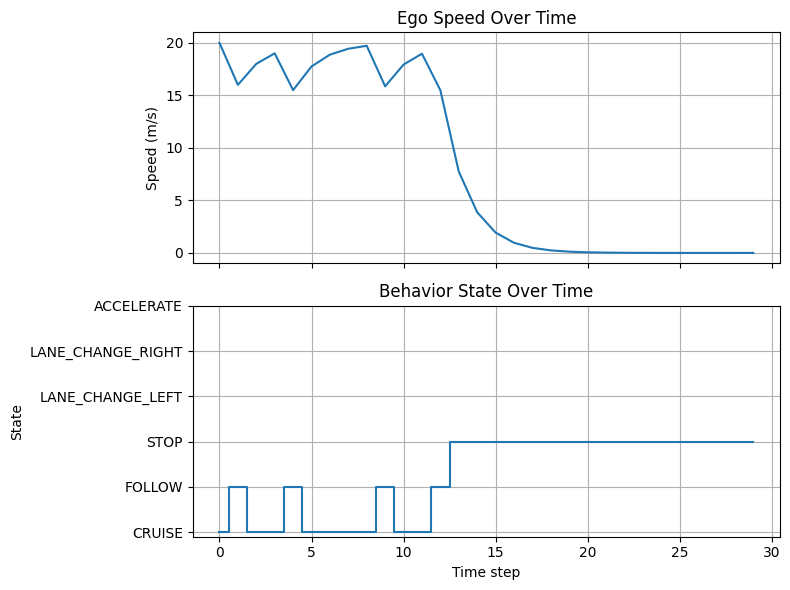

In [ ]:
import matplotlib.pyplot as plt

times = history['time']
speed = history['speed']
states_hist = history['state']

state_levels = {s: i for i, s in enumerate(states)}
levels = [state_levels[s] for s in states_hist]

fig, axs = plt.subplots(2, 1, figsize=(8,6), sharex=True)

axs[0].plot(times, speed)
axs[0].set_ylabel('Speed (m/s)')
axs[0].set_title('Ego Speed Over Time')
axs[0].grid(True)

axs[1].step(times, levels, where='mid')
axs[1].set_yticks(list(state_levels.values()))
axs[1].set_yticklabels(states)
axs[1].set_xlabel('Time step')
axs[1].set_ylabel('State')
axs[1].set_title('Behavior State Over Time')
axs[1].grid(True)

plt.tight_layout()
plt.show()

### Visualize Final Highway Snapshot
We can also visualize the final positions of vehicles after the simulation and highlight the ego vehicle.

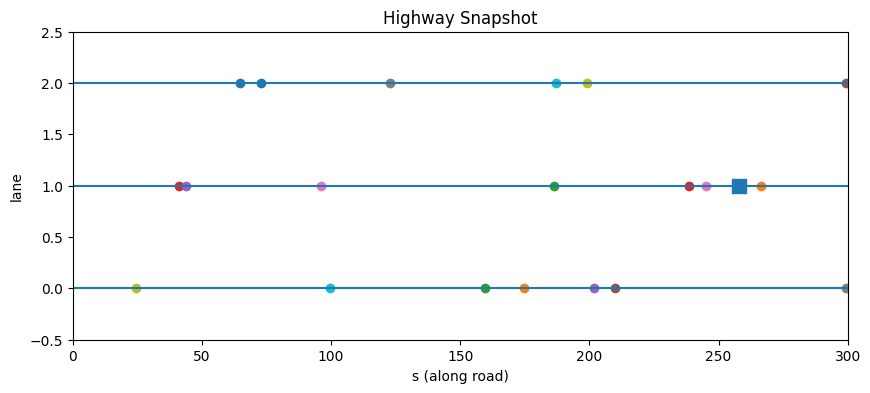

In [ ]:
# Take the last ego position from history
final_ego_lane = history['lane'][-1]
final_ego_s = history['s'][-1]

# Update ego in vehicles_sim for plotting
for v in vehicles_sim:
    if v.is_ego:
        v.lane = final_ego_lane
        v.s = final_ego_s

plot_highway(vehicles_sim, [v for v in vehicles_sim if v.is_ego][0])

## 6. Summary and Next Steps
In this advanced behavior-planning notebook, we:
- Defined an FSM with multiple behavior states relevant to highway driving
- Created a cost-based transition system that accounts for distances to nearby vehicles
- Visualized the abstract state graph using a directed graph
- Simulated a simple multi-lane highway and used the FSM to control the ego vehicle's behavior

### Ideas to Extend
- Add rear vehicles and ensure lane changes are safe behind as well.
- Use more realistic kinematics and continuous-time integration.
- Connect this behavior planner to a local planner (Frenet trajectories) and global route.
- Replace random cars with recorded or realistic traffic data.
